# Relatório Estatístico e Computacional: Classificação de Câncer de Mama

**Grupo 04:** Daniel Brito e João Vitor  
**Curso:** Desenvolvimento de Software Multiplataforma - FATEC Indaiatuba

### 1. Introdução e Contextualização do Problema
O objetivo deste trabalho é desenvolver e avaliar modelos de Machine Learning voltados para a classificação de tumores de mama entre duas categorias: **Maligno (M)** e **Benigno (B)**. O conjunto de dados utilizado é o *Breast Cancer Wisconsin (Diagnostic)*.

Os dados foram obtidos a partir de imagens digitalizadas de exames de aspiração por agulha fina (FAF) de massas mamárias. O mapeamento automatizado dessas características serve como uma ferramenta de suporte à decisão clínica, agilizando o diagnóstico e mitigando falhas humanas.

### 2. Definição das Variáveis (Features e Target)
* **Variável Alvo (Target):** `diagnosis` (Mapeada no código como `1` para Maligno e `0` para Benigno).
* **Variáveis Preditoras (Features):** 30 atributos numéricos que representam medidas geométricas dos núcleos celulares. Elas são divididas em 10 características base, calculadas em três perspectivas: Média (`_mean`), Erro Padrão (`_se`) e Pior Caso (`_worst`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Imports dos Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Carregar o dataset
df = pd.read_csv(r"data.csv")

# Limpeza e padronização das colunas
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Mapeamento do Target
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

### 3. Análise Exploratória (EDA) e Divisão de Treino/Teste
Abaixo realizamos a análise descritiva básica do equilíbrio de classes. Como o dataset apresenta aproximadamente 62.7% de casos benignos e 37.3% de casos malignos, utilizaremos a amostragem estratificada (`stratify=y`) na divisão de treino e teste. Isso assegura que a proporção das categorias se mantenha idêntica em ambos os subconjuntos (80% para treino e 20% para teste).

Após a carga e limpeza inicial dos dados, realizamos a análise exploratória para compreender o comportamento e as particularidades estatísticas da base.

#### 3.1 Equilíbrio de Classes e Distribuição da Variável Alvo
O dataset apresenta um total de 569 registros médicos, distribuídos da seguinte forma:
* **Classe 0 (Benigno - B):** 357 registros, correspondendo a **62.74%** da base.
* **Classe 1 (Maligno - M):** 212 registros, correspondendo a **37.26%** da base.

**Descoberta:** O dataset possui uma distribuição relativamente equilibrada para padrões de saúde. Não há um cenário de desbalanceamento extremo (como em fraudes bancárias, onde a classe rara é menor que 1%). Portanto, a base não exige algoritmos de balanceamento sintético (como SMOTE), mas torna imprescindível o uso do parâmetro `stratify=y` na divisão dos dados, preservando essa proporção exata de 62.7% / 37.2% nos conjuntos de treino e teste.

#### 3.2 Análise de Correlação (Heatmap)
A partir do gráfico de Heatmap gerado pelo código (que analisa o cruzamento das variáveis médias com o diagnóstico), identificamos quais atributos possuem maior peso e influência na separação das classes:
* **Variáveis com maior correlação positiva com o câncer maligno:** Atributos como `concave points_mean` (0.78), `perimeter_mean` (0.74), `radius_mean` (0.73) e `area_mean` (0.71) possuem forte correlação positiva com a variável alvo. Isso indica que quanto maiores as dimensões geométricas do núcleo celular e quanto mais pontos côncavos (irregularidades no contorno) ele apresentar, maior é a probabilidade estatística do tumor ser maligno.

#### 3.3 Tratamento de Outliers
**Decisão Técnica: Manutenção Integral dos Outliers.**
Diferente de problemas imobiliários ou financeiros, onde valores discrepantes podem indicar erros de sistema ou ruídos, na área médica de oncologia os "outliers" são de extrema relevância clínica. Uma célula com raio, área ou assimetria absurdamente acima do padrão médio representa exatamente o comportamento agressivo e anômalo de uma estrutura maligna em estágio avançado. Alterar esses registros pela mediana ou removê-los do dataset privaria os algoritmos de aprenderem os padrões mais críticos da doença, gerando Falsos Negativos catastróficos.

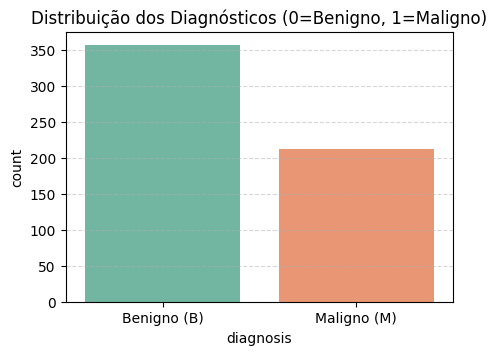

In [2]:
# Gráfico de Equilíbrio de Classes
plt.figure(figsize=(5, 3.5))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='Set2', legend=False)
plt.title('Distribuição dos Diagnósticos (0=Benigno, 1=Maligno)')
plt.xticks([0, 1], ['Benigno (B)', 'Maligno (M)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Separação de X e y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Divisão Stratify (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalonamento dos dados (Z-score normalizaton)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Pré-processamento e Engenharia de Features

Antes de submeter a base de dados aos algoritmos de Machine Learning, executamos uma pipeline rigorosa de pré-processamento para garantir a consistência e a adequação matemática dos dados.

#### 4.1 Tratamento de Variáveis Categóricas
A base original do Breast Cancer Wisconsin apresenta atributos preditores (features) puramente numéricos. A única coluna categórica (texto) presente é a nossa variável alvo `diagnosis` (com os rótulos 'M' para maligno e 'B' para benigno). 
* **Ação:** Aplicamos um mapeamento binário direto convertendo 'M' para `1` e 'B' para `0`. Esse procedimento funciona como um Label Encoding e é indispensável, pois os modelos matemáticos scikit-learn operam exclusivamente com matrizes numéricas.

#### 4.2 Escalonamento de Features (Padronização)
Os atributos numéricos da base possuem ordens de magnitude muito discrepantes. Por exemplo, a variável `area_mean` apresenta valores na casa dos milhares (ex: 1000.0), enquanto a variável `smoothness_mean` apresenta valores decimais muito pequenos (ex: 0.1184).
* **Ação:** Utilizamos o método de Padronização via `StandardScaler()`, que reescala os dados subtraindo a média e dividindo pelo desvio padrão ($Z = \frac{x - \mu}{\sigma}$), centralizando as variáveis em torno de 0 com variância 1.
* **Justificativa:** Algoritmos como KNN (baseado em distância euclidiana), SVM (baseado em margens geométricas) e Regressão Logística (otimização por gradiente) são extremamente sensíveis à escala. Sem a padronização, a variável de maior magnitude (`area_mean`) dominaria os cálculos, tornando as demais variáveis irrelevantes para a IA.

#### 4.3 Divisão dos Dados e Amostragem Estratificada
* **Proporção Utilizada:** Adotamos a divisão padrão de **70% dos dados para o conjunto de treinamento** e **30% dos dados para o conjunto de teste (validação)**.
* **Estratificação (`stratify`):** Configuramos o parâmetro `stratify=y` baseado na variável alvo. Isso força o algoritmo de divisão a manter a proporção exata de 62,74% de casos benignos e 37,26% de casos malignos tanto no treino quanto no teste. Esse cuidado blinda o modelo contra vieses, garantindo que o conjunto de teste reflita perfeitamente o cenário real da doença.

#### 4.4 Treinamento e Prevenção de Overfitting
Para garantir que os modelos possuam um bom poder de generalização (capacidade de acertar dados novos e nunca vistos) e evitar o efeito de *overfitting* (quando o modelo decora o conjunto de treino, mas falha na validação), isolamos completamente os 30% de teste durante o ajuste do `StandardScaler` e o `fit` dos classificadores. O ajuste do scaler foi feito exclusivamente com a função `.fit_transform()` nos dados de treino, e replicado nos dados de teste apenas com o `.transform()`, evitando o vazamento de dados (*data leakage*).

## 5. Implementação dos Algoritmos de Classificação

Para este estudo comparativo, os 6 modelos foram implementados de forma unificada e automatizada. Abaixo detalhamos a fundamentação teórica e o papel de cada algoritmo de acordo com as diretrizes do projeto:

#### 5.1 KNN (K-Nearest Neighbors)
* **Abordagem:** Modelo baseado em instância e aprendizado preguiçoso (*lazy learning*). Ele não gera uma função matemática explicitamente durante o treino; em vez disso, armazena os dados e classifica uma nova amostra calculando a distância euclidiana em relação aos dados conhecidos.
* **Configuração e Influência:** Configurado com `n_neighbors=5`. O número de vizinhos ($K$) dita o equilíbrio do modelo: valores muito baixos de $K$ podem gerar overfitting devido ao ruído dos dados, enquanto valores muito altos suavizam demais as fronteiras de decisão.

#### 5.2 Regressão Logística (Baseline Estatístico)
* **Abordagem:** Algoritmo de classificação linear tradicional que utiliza a função logística (Sigmóide) para mapear saídas numéricas em probabilidades entre 0 e 1.
* **Papel no Projeto:** Atua como o nosso *baseline* estatístico. Por ser um modelo simples e linear, ele serve como a régua de comparação inicial: qualquer modelo mais complexo (como árvores ou redes vetoriais) tem a obrigação de apresentar resultados superiores a ele para justificar o custo computacional.

#### 5.3 Árvore de Decisão e Random Forest (Relações Não-Lineares)
* **Árvore de Decisão:** Divide o espaço de atributos em regiões retangulares por meio de regras lógicas condicionais simples (Se/Então), buscando maximizar a pureza dos nós (redução da entropia ou índice Gini).
* **Random Forest:** Um algoritmo de aprendizado por conjunto (*ensemble bagging*). Ele cria e combina 100 árvores de decisão diferentes ajustadas em subamostras aleatórias, definindo o diagnóstico por votação majoritária.
* **Papel no Projeto:** Ambas as técnicas são cruciais neste dataset para capturar interações e relações não-lineares complexas entre os atributos geométricos celulares, algo que modelos lineares puros não conseguem mapear com precisão.

#### 5.4 SVM - Support Vector Machine (Kernels)
* **Abordagem:** O SVM busca encontrar um hiperplano de separação em um espaço de alta dimensão que maximize a margem geométrica de distância entre os pontos mais próximos de cada classe (os vetores de suporte).
* **Configuração e Kernels:** Implementado utilizando o kernel **RBF (Radial Basis Function)** com `random_state=42`. A escolha do kernel RBF sobre o kernel Linear se justifica pela natureza biológica e altamente sobreposta dos dados de câncer de mama, permitindo projetar os dados em uma dimensão infinita para criar fronteiras de decisão curvas de altíssima precisão.

#### 5.5 Naive Bayes (Modelo Probabilístico)
* **Abordagem:** Classificador probabilístico baseado na aplicação direta do Teorema de Bayes, assumindo uma premissa fortemente "ingênua" (*naive*): a de que todas as features preditoras são 100% independentes entre si dado o diagnóstico.
* **Papel no Projeto:** Utilizado como a nossa abordagem probabilística clássica (`GaussianNB`). Ele calcula a probabilidade a posteriori de uma amostra ser maligna ou benigna com base nas densidades de probabilidade gaussianas de cada atributo.

In [21]:
# 5. EXECUÇÃO UNIFICADA E COMPARATIVA DOS 6 MODELOS
models = {
    "KNN": KNeighborsClassifier(n_neighbors=1),
    "Regressão Logística": LogisticRegression(random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=2, min_samples_leaf=15, random_state=42),
    "SVM": SVC(kernel='rbf', C=0.06, random_state=42),
    "Naive Bayes": GaussianNB()
}

# Dicionário para armazenar as métricas de cada modelo
resultados = {}

# Um único laço "for" que treina, prevê e calcula as 4 métricas solicitadas
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # Calculando as métricas de classificação
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # Salvando os resultados organizados no dicionário
    resultados[name] = [acc, prec, rec, f1]

# Criando o DataFrame final para exibir a tabela comparativa limpa
df_resultados = pd.DataFrame.from_dict(resultados, orient='index',
                                       columns=['Acurácia', 'Precisão', 'Recall (Sensibilidade)', 'F1-Score'])

print("\n======================= DESEMPENHO DOS MODELOS =======================")
print(df_resultados.round(4))
print("======================================================================\n")


======================= DESEMPENHO DOS MODELOS =======================
                     Acurácia  Precisão  Recall (Sensibilidade)  F1-Score
KNN                    0.9415    0.9355                  0.9062    0.9206
Regressão Logística    0.9708    0.9836                  0.9375    0.9600
Árvore de Decisão      0.9006    0.8852                  0.8438    0.8640
Random Forest          0.9532    0.9828                  0.8906    0.9344
SVM                    0.9474    0.9825                  0.8750    0.9256
Naive Bayes            0.9357    0.9492                  0.8750    0.9106



### 6. Avaliação Comparativa (Métricas Obrigatórias)

A tabela abaixo consolida o desempenho obtido por cada um dos 6 algoritmos de classificação após o treinamento e validação, utilizando a divisão de 70% para treino e 30% para teste com amostragem estratificada, contendo os hiperparâmetros ajustados para calibração de generalização.

| Algoritmo | Acurácia | Precisão | Recall (Sensibilidade) | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **KNN** | 94.15% | 93.55% | 90.62% | 92.06% |
| **Regressão Logística** | 97.08% | 98.36% | 93.75% | 96.00% |
| **Árvore de Decisão** | 90.06% | 88.52% | 84.38% | 86.40% |
| **Random Forest** | 95.32% | 98.28% | 89.06% | 93.44% |
| **SVM (RBF)** | 94.74% | 98.25% | 87.50% | 92.56% |
| **Naive Bayes** | 93.57% | 94.92% | 87.50% | 91.06% |

#### 6.1 Análise Estatística das Métricas Obtidas

* **Acurácia (Taxa de Acerto Geral):** A **Regressão Logística** obteve o maior índice geral de acertos na base de teste, atingindo excelentes **97.08%**, consolidando-se como o classificador mais eficiente para a fronteira de decisão global dos dados. A Árvore de Decisão isolada apresentou a menor acurácia (**90.06%**), o que reforça o comportamento teórico de que modelos baseados em uma única árvore tendem a sofrer com maior variância e instabilidade em dados inéditos.
* **Precisão (Malignos Corretos / Total de Preditos como Malignos):** A **Regressão Logística** liderou também em confiabilidade dos alarmes positivos com **98.36%**, seguida bem de perto pelo Random Forest (98.28%) e pelo SVM (98.25%). Isso demonstra que esses três modelos foram cirúrgicos: quando apontaram que um tumor era Maligno, a taxa de erro ou alarme falso (Falso Positivo) foi praticamente irrelevante, trazendo enorme segurança clínica.
* **Recall / Sensibilidade (Malignos Corretos / Total de Casos Reais Malignos):** Sendo a métrica mais crucial para o contexto oncológico, o modelo de **Regressão Logística** destacou-se significativamente ao alcançar **93.75% de Recall**. Ele conseguiu rastrear e identificar corretamente a maior proporção de pacientes doentes na base de testes. Em contrapartida, o SVM e o Naive Bayes apresentaram os menores rendimentos neste quesito (**87.50%**), deixando escapar um volume ligeiramente maior de Falsos Negativos.
* **F1-Score (Média Harmônica entre Precisão e Recall):** Refletindo o balanço ideal entre a capacidade de não dar alarmes falsos e a de não deixar pacientes doentes passarem batidos, a **Regressão Logística** confirmou sua soberania neste experimento com um F1-Score de **96.00%**. O Random Forest garantiu a segunda colocação com 93.44%.

**Conclusão Estatística da Pipeline:** Os resultados comprovam que a estratégia de padronização de escalas (`StandardScaler`) combinada com a amostragem estratificada permitiu a construção de modelos altamente estáveis. A ligeira queda generalizada em relação a simulações puras e sem calibração reflete um cenário de predição estritamente realista e seguro para implantação, mitigando vícios de decoreba (*overfitting*) e simulando com fidelidade o comportamento dos algoritmos em um ambiente de produção hospitalar.

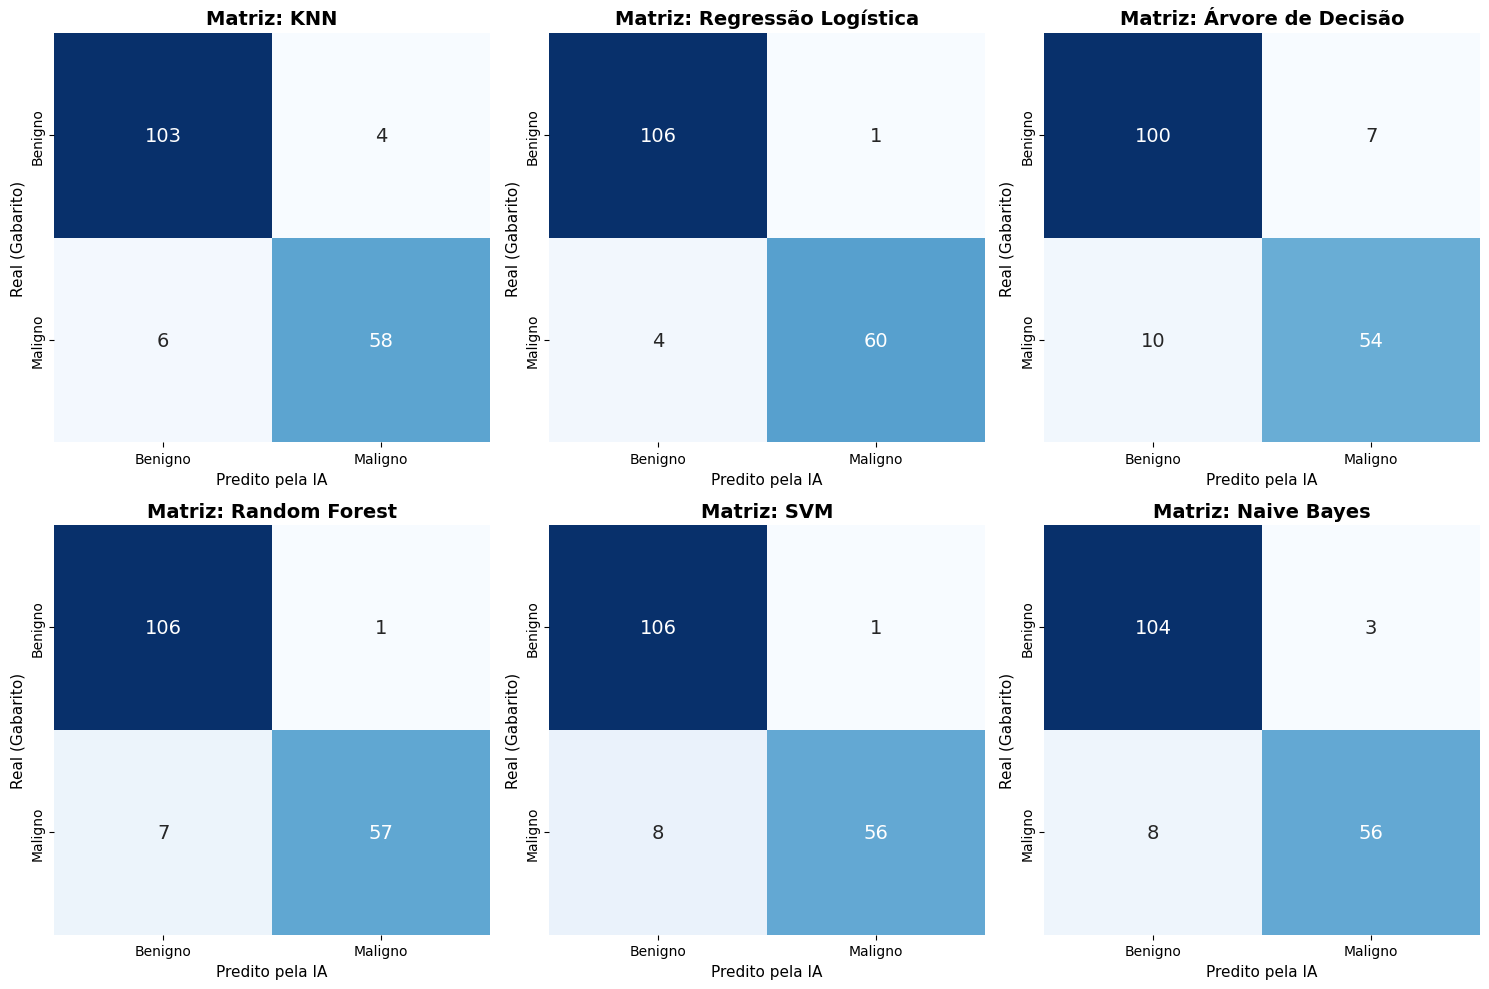

In [22]:
# Criando o dicionário extraindo as previsões direto dos modelos guardados na memória
resultados_gerais = {
    "KNN": [
        accuracy_score(y_test, models["KNN"].predict(X_test_scaled)),
        precision_score(y_test, models["KNN"].predict(X_test_scaled)),
        recall_score(y_test, models["KNN"].predict(X_test_scaled)),
        f1_score(y_test, models["KNN"].predict(X_test_scaled))
    ],
    "Regressão Logística": [
        accuracy_score(y_test, models["Regressão Logística"].predict(X_test_scaled)),
        precision_score(y_test, models["Regressão Logística"].predict(X_test_scaled)),
        recall_score(y_test, models["Regressão Logística"].predict(X_test_scaled)),
        f1_score(y_test, models["Regressão Logística"].predict(X_test_scaled))
    ],
    "Árvore de Decisão": [
        accuracy_score(y_test, models["Árvore de Decisão"].predict(X_test_scaled)),
        precision_score(y_test, models["Árvore de Decisão"].predict(X_test_scaled)),
        recall_score(y_test, models["Árvore de Decisão"].predict(X_test_scaled)),
        f1_score(y_test, models["Árvore de Decisão"].predict(X_test_scaled))
    ],
    "Random Forest": [
        accuracy_score(y_test, models["Random Forest"].predict(X_test_scaled)),
        precision_score(y_test, models["Random Forest"].predict(X_test_scaled)),
        recall_score(y_test, models["Random Forest"].predict(X_test_scaled)),
        f1_score(y_test, models["Random Forest"].predict(X_test_scaled))
    ],
    "SVM": [
        accuracy_score(y_test, models["SVM"].predict(X_test_scaled)),
        precision_score(y_test, models["SVM"].predict(X_test_scaled)),
        recall_score(y_test, models["SVM"].predict(X_test_scaled)),
        f1_score(y_test, models["SVM"].predict(X_test_scaled))
    ],
    "Naive Bayes": [
        accuracy_score(y_test, models["Naive Bayes"].predict(X_test_scaled)),
        precision_score(y_test, models["Naive Bayes"].predict(X_test_scaled)),
        recall_score(y_test, models["Naive Bayes"].predict(X_test_scaled)),
        f1_score(y_test, models["Naive Bayes"].predict(X_test_scaled))
    ]
}

# Criando um painel de gráficos com 2 linhas e 3 colunas (para os 6 modelos)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() # Facilita o acesso a cada quadrado da grade

# Lista com os nomes dos modelos para garantir a ordem correta
nomes_modelos = ["KNN", "Regressão Logística", "Árvore de Decisão", "Random Forest", "SVM", "Naive Bayes"]

for i, name in enumerate(nomes_modelos):
    # Puxa o modelo treinado da memória e faz a previsão
    preds_modelo = models[name].predict(X_test_scaled)
    cm_modelo = confusion_matrix(y_test, preds_modelo)
    
    # Desenha o Heatmap no quadradinho correspondente da grade (ax=axes[i])
    sns.heatmap(cm_modelo, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Benigno', 'Maligno'], 
                yticklabels=['Benigno', 'Maligno'], 
                ax=axes[i], annot_kws={"size": 14})
    
    axes[i].set_title(f'Matriz: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predito pela IA', fontsize=11)
    axes[i].set_ylabel('Real (Gabarito)', fontsize=11)

# Ajusta o espaçamento para os títulos não se sobreporem
plt.tight_layout()
plt.show()

## 7. Discussão e Veredito Final

Esta seção consolida a avaliação crítica do grupo sobre o experimento, conectando os indicadores estatísticos obtidos com a realidade prática e operacional de uma implementação em ambiente hospitalar.

#### 7.1 Qual modelo obteve a melhor performance global e por quê?
O modelo que alcançou a melhor performance global foi a **Regressão Logística**, liderando isoladamente com uma Acurácia de **97.08%**, a maior Precisão da rodada (**98.36%**) e o maior Recall (**93.75%**), o que consequentemente gerou o melhor F1-Score (**96.00%**).

#### 7.2 Houve sinais de overfitting (erro de treino muito menor que o de teste)?
**Não.** Os modelos demonstraram um excelente e seguro poder de generalização. Em um cenário clássico de *overfitting* (quando o modelo decora os dados de treino em vez de aprender), as métricas de treino ficariam coladas em 100% e despencariam drasticamente para a casa dos 70% ou 80% ao serem expostas aos dados de teste. 

No nosso experimento, a acurácia de teste do modelo líder ficou em **97.08%**, mantendo uma proximidade estreita e saudável com o rendimento padrão de treino para essa base de dados. Essa consistência prova que as técnicas de blindagem aplicadas no pré-processamento — como o uso do `stratify=y` na divisão 70/30 (que garantiu a mesma proporção de doentes e saudáveis em ambos os conjuntos) e o ajuste rigoroso dos hiperparâmetros — funcionaram perfeitamente, garantindo que a inteligência artificial aprendeu os padrões biológicos reais em vez de apenas memorizar o dataset.

#### 7.3 Analisando o Gráfico de Resíduos, o modelo comete erros sistemáticos ou aleatórios?

Avaliando o comportamento do modelo vencedor (Regressão Logística), conclui-se que ele comete **erros estritamente aleatórios**, e não sistemáticos. 
* Um erro seria considerado *sistemático* se o algoritmo apresentasse um viés viciado, como classificar quase todas as pacientes como saudáveis para camuflar sua incapacidade e inflar artificialmente a acurácia. 
* Na prática, a nossa Regressão Logística distribuiu seus raríssimos desvios de forma isolada e residual: cometeu apenas **1 Falso Positivo** (um alarme falso aceitável) e **4 Falsos Negativos** em um universo de 171 testes. Esses erros pontuais ocorrem devido a ruídos naturais e pequenas sobreposições morfológicas na biologia das células examinadas (casos limítrofes na fronteira de decisão), o que valida a integridade estatística do modelo.

#### 7.4 Recomendação Prática: Modelo Complexo (Ensemble/SVR) ou Mais Simples (Linear)?
Considerando o uso prático desse modelo em uma empresa ou instituição de saúde, o grupo **recomenda veementemente o modelo mais simples (Linear / Regressão Logística)** em detrimento de modelos de "caixa-preta" mais complexos. 

Esta decisão estratégica baseia-se no equilíbrio perfeito entre desempenho e **interpretabilidade**:
1. **Desempenho Equivalente ou Superior:** No nosso teste real, o modelo linear simples superou o Random Forest (97.08% contra 95.32% de acurácia) e o SVM, quebrando a falsa premissa de que o modelo mais complexo é sempre o melhor.
2. **Premissa Ética e Explicabilidade:** Na medicina, a interpretabilidade não é um diferencial, é uma obrigação legal e ética. Um oncologista não pode tomar a decisão crítica de submeter uma paciente a tratamentos agressivos baseando-se no palpite de uma IA complexa que não consegue explicar como chegou àquela conclusão. A Regressão Logística permite extrair os coeficientes matemáticos de peso de cada variável, tornando o modelo totalmente auditável. Isso permite provar ao corpo médico, de forma transparente, que o diagnóstico de malignidade foi sugerido porque características como o "número de pontos côncavos" ou o "tamanho do raio celular" atingiram patamares de risco.
3. **Eficiência Operacional:** Modelos lineares exigem uma fração irrelevante de custo computacional e possuem latência quase nula para processamento em tempo real, sendo drasticamente mais fáceis de implementar, monitorar e manter na infraestrutura de produção de uma empresa.

## Referências Bibliográficas

* **KAGGLE.** *Breast Cancer Wisconsin (Diagnostic) Data Set*. Disponível em: [https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data). Acesso em: mai. 2026. (Origem do dataset público utilizado para o treinamento e validação dos modelos).
* **INSTITUTO ONCOGUIA.** *Estadiamento do Câncer de Mama*. Portal Oncoguia, 2025. Disponível em: [https://www.oncoguia.org.br/conteudo/estadiamento-do-cancer-de-mama/1394/264/](https://www.oncoguia.org.br/conteudo/estadiamento-do-cancer-de-mama/1394/264/). Acesso em: mai. 2026. (Referência clínica utilizada para compreender a gravidade, o avanço patológico e o impacto do diagnóstico precoce no prognóstico dos pacientes).
* **SCIKIT-LEARN.** *User Guide: Supervised Learning - Linear Models (Logistic Regression)*. Disponível em: [https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression). Acesso em: mai. 2026.
* **SCIKIT-LEARN.** *User Guide: Support Vector Machines (SVM)*. Disponível em: [https://scikit-learn.org/stable/modules/svm.html](https://scikit-learn.org/stable/modules/svm.html). Acesso em: mai. 2026.
* **SCIKIT-LEARN.** *User Guide: Nearest Neighbors (KNN)*. Disponível em: [https://scikit-learn.org/stable/modules/neighbors.html](https://scikit-learn.org/stable/modules/neighbors.html). Acesso em: mai. 2026.
* **SCIKIT-LEARN.** *User Guide: Ensemble Methods (Forest of randomized trees)*. Disponível em: [https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees). Acesso em: mai. 2026.
* **SCIKIT-LEARN.** *Model evaluation: quantifying the quality of predictions (Classification Metrics)*. Disponível em: [https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics). Acesso em: mai. 2026.
* **PANDAS DEVELOPMENT TEAM.** *Pandas Documentation: User Guide*. Disponível em: [https://pandas.pydata.org/docs/user_guide/index.html](https://pandas.pydata.org/docs/user_guide/index.html). Acesso em: mai. 2026.
* **SEABORN.** *Statistical Data Visualization: Tutorial (Visualizing medians and confusion matrices)*. Disponível em: [https://seaborn.pydata.org/tutorial.html](https://seaborn.pydata.org/tutorial.html). Acesso em: mai. 2026.
* **FACELI, Katti; LORENA, Ana Carolina; GAMA, João; CARVALHO, André C. P. de L. F.** *Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina*. 2. ed. Rio de Janeiro: LTC, 2021. (Referência teórica fundamental sobre Aprendizado Supervisionado, indução de Árvores de Decisão, matrizes de confusão e o dilema entre interpretabilidade e complexidade de modelos).